# Análisis de Marketing — Alojamientos Turísticos
Cuál es el precio medio de los alojamientos por tipos
de alojamiento en cada ciudad?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns

# df = pd.read_csv('cleaned_tourist_accommodation_20_04.csv')
df = pd.read_csv("../Data/cleaned_tourist_accommodation_20_04.csv")

# ── Paleta de colores ─────────────────────────────────────────────────────────
AZUL_OSCURO    = '#1A4E6E'
AZUL_PRINCIPAL = '#2C7BB6'
TURQUESA       = '#74C2C9'
AZUL_CLARO     = '#B8DDE4'
FONDO_SUAVE    = '#E8F4F7'
GRIS_TEXTO     = '#4A4A4A'
GRIS_BORDE     = '#CCCCCC'
GRIS_GRID      = '#E0E0E0'

COLORES_TIPOS = [AZUL_OSCURO, AZUL_PRINCIPAL, TURQUESA, AZUL_CLARO]

# ── Variables compartidas ─────────────────────────────────────────────────────
TIPOS = ['Entire home/apt', 'Hotel room', 'Private room', 'Shared room']

pivot_precio = (
    df.groupby(['city', 'room_type'])['price_imputed']
    .mean()
    .unstack('room_type')
    .reindex(columns=TIPOS)
)
city_order   = pivot_precio['Entire home/apt'].sort_values(ascending=False).index
pivot_precio = pivot_precio.loc[city_order]
CITY_LABELS  = [c.capitalize() for c in pivot_precio.index]

## Fig 1 — Metric cards: precio medio por tipo

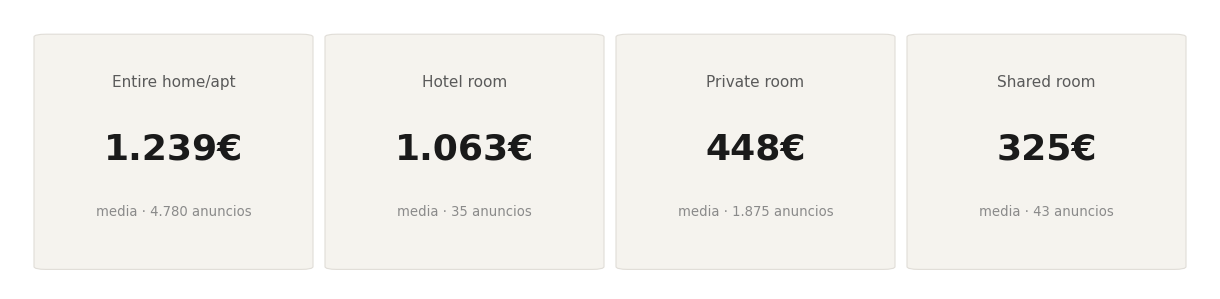

In [2]:
cards = []
for tipo in TIPOS:
    sub = df[df['room_type'] == tipo]
    cards.append({
        'label': tipo,
        'media': f"{sub['price_imputed'].mean():,.0f}€".replace(',', '.'),
        'sub':   f"media · {len(sub):,} anuncios".replace(',', '.')
    })

fig, ax = plt.subplots(figsize=(12, 2.8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')
ax.axis('off')

n   = len(cards)
gap = 0.03
w   = (1 - (n + 1) * gap) / n

for i, card in enumerate(cards):
    x = gap + i * (w + gap)
    fancy = mpatches.FancyBboxPatch(
        (x, 0.08), w, 0.82,
        boxstyle='round,pad=0.01',
        transform=fig.transFigure,
        facecolor='#F5F3EE', edgecolor='#E0DDD7',
        linewidth=0.8, clip_on=False, zorder=2
    )
    fig.add_artist(fancy)
    cx = x + w / 2
    fig.text(cx, 0.74, card['label'], ha='center', va='center',
             fontsize=11, color='#5A5A5A', transform=fig.transFigure, zorder=3)
    fig.text(cx, 0.50, card['media'], ha='center', va='center',
             fontsize=26, fontweight='bold', color='#1A1A1A', transform=fig.transFigure, zorder=3)
    fig.text(cx, 0.28, card['sub'], ha='center', va='center',
             fontsize=9.5, color='#8A8A8A', transform=fig.transFigure, zorder=3)

plt.tight_layout(pad=0)
# plt.savefig('fig1_metric_cards.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Este gráfico de tarjetas comparativas presenta el precio medio global para las cuatro categorías principales de alojamiento. Destaca que los apartamentos completos (Entire home/apt) tienen el coste promedio más elevado con 1.239€ , seguidos de cerca por las habitaciones de hotel con 1.063€. En contraste, las opciones de habitaciones privadas (448€) y habitaciones compartidas (325€) representan las alternativas más económicas para el usuario.

## Fig 2 — Precio medio global por tipo de alojamiento

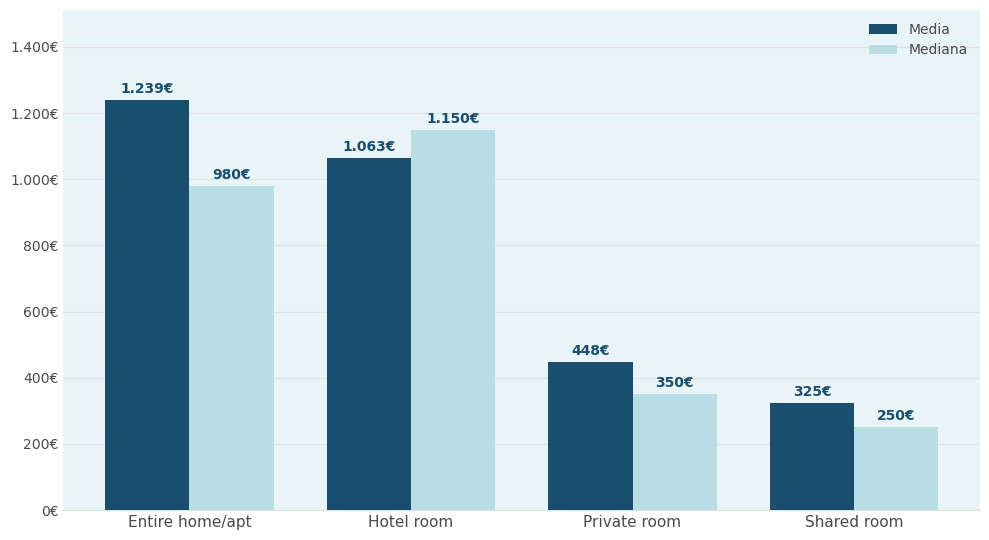

In [3]:
medias   = [df[df['room_type'] == t]['price_imputed'].mean()   for t in TIPOS]
medianas = [df[df['room_type'] == t]['price_imputed'].median() for t in TIPOS]

x      = np.arange(len(TIPOS))
width  = 0.38

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

b1 = ax.bar(x - width/2, medias,   width, label='Media',   color=AZUL_OSCURO,    zorder=3)
b2 = ax.bar(x + width/2, medianas, width, label='Mediana', color=AZUL_CLARO, zorder=3)

# Etiquetas media
for bar, val in zip(b1, medias):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 12,
            f'{val:,.0f}€'.replace(',', '.'),
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=AZUL_OSCURO)

# Etiquetas mediana
for bar, val in zip(b2, medianas):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 12,
            f'{val:,.0f}€'.replace(',', '.'),
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=AZUL_OSCURO)

ax.set_xticks(x)
ax.set_xticklabels(TIPOS, fontsize=11, color=GRIS_TEXTO)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}€'.replace(',', '.')))
ax.set_ylim(0, max(medias) * 1.22)
ax.legend(frameon=False, fontsize=10, labelcolor=GRIS_TEXTO)
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='x', labelsize=11, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='y', labelsize=10, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
# plt.savefig('fig2_precio_tipo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

A través de un gráfico de barras agrupadas, se analiza la diferencia entre la media y la mediana de precios para cada tipo de estancia. Se observa que en la categoría de Entire home/apt, la media (1.239€) es superior a la mediana (980€), lo que indica la presencia de alojamientos de lujo con precios muy altos que elevan el promedio. Por el contrario, en las Hotel rooms, la mediana (1.150€) supera a la media (1.063€), sugiriendo una mayor concentración de precios en rangos superiores dentro de esta categoría específica

## Fig 3 — Distribución de alojamientos por ciudad

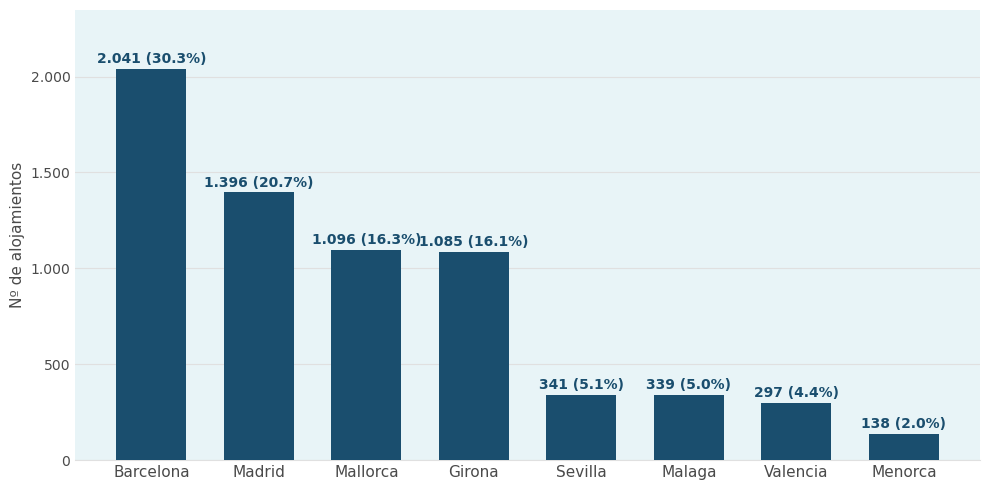

In [4]:
city_counts = (
    df.groupby('city')['apartment_id']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
city_counts.columns = ['city', 'count']
city_counts['city'] = city_counts['city'].str.capitalize()

# ── Porcentaje sobre el total ─────────────────────────────────────────────────
total = city_counts['count'].sum()
city_counts['pct'] = (city_counts['count'] / total * 100).round(1)

n       = len(city_counts)
palette = [AZUL_OSCURO]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

bars = ax.bar(city_counts['city'], city_counts['count'],
              color=palette[:n], width=0.65, zorder=3)

for bar, val, pct in zip(bars, city_counts['count'], city_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{val:,} ({pct}%)".replace(',', '.'),   # ← número + porcentaje
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=AZUL_OSCURO)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.')))
ax.set_ylim(0, city_counts['count'].max() * 1.15)
ax.set_ylabel('Nº de alojamientos', fontsize=11, color=GRIS_TEXTO)
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='x', labelsize=11, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='y', labelsize=10, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
# plt.savefig('fig3_alojamientos_ciudad.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Este gráfico de barras descendente muestra la cuota de mercado según el número de alojamientos disponibles en cada ubicación analizada. Barcelona lidera claramente la oferta con 2.041 alojamientos, lo que representa el 30,3% del total. Le siguen Madrid con un 20,7% y Mallorca con un 16,3%. En el extremo opuesto, ciudades como Valencia (4,4%) y Menorca (2,0%) presentan una oferta mucho más limitada y exclusiva en el conjunto de datos.

## Fig 4 — Distribución de alojamientos por tipo

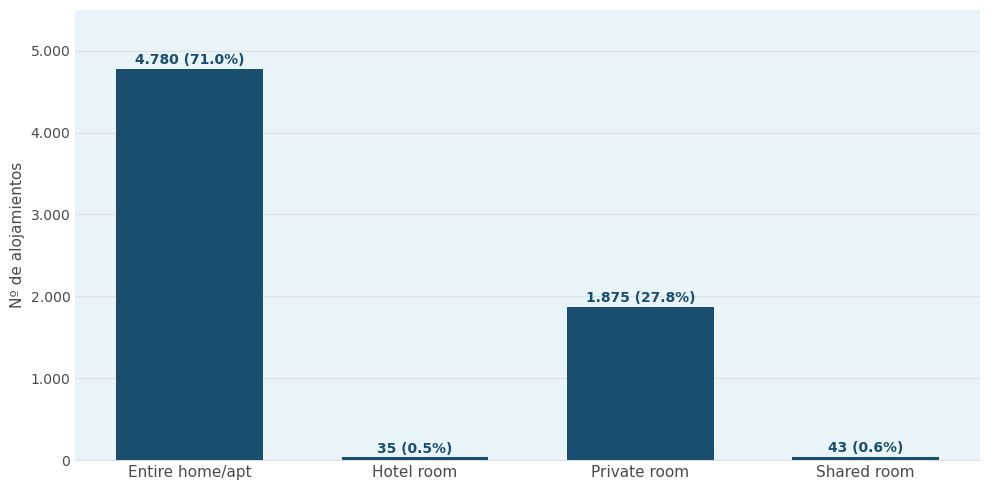

In [5]:
tipo_counts = (
    df.groupby('room_type')['apartment_id']
    .count()
    .reindex(TIPOS)
    .reset_index()
)
tipo_counts.columns = ['room_type', 'count']

# ── Porcentaje sobre el total ─────────────────────────────────────────────────
total = tipo_counts['count'].sum()
tipo_counts['pct'] = (tipo_counts['count'] / total * 100).round(1)

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

bars = ax.bar(tipo_counts['room_type'], tipo_counts['count'],
              color=AZUL_OSCURO, width=0.65, zorder=3)

for bar, val, pct in zip(bars, tipo_counts['count'], tipo_counts['pct']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{val:,} ({pct}%)".replace(',', '.'),
            ha='center', va='bottom', fontsize=10, fontweight='bold', color=AZUL_OSCURO)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.')))
ax.set_ylim(0, tipo_counts['count'].max() * 1.15)
ax.set_ylabel('Nº de alojamientos', fontsize=11, color=GRIS_TEXTO)
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='x', labelsize=11, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='y', labelsize=10, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
# plt.savefig('fig4_alojamientos_tipo.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Este gráfico de barras ilustra la distribución del volumen de alojamientos según su tipología, revelando una clara predominancia de los alquileres de propiedades completas en el mercado analizado. La categoría de Entire home/apt lidera ampliamente la oferta con 4.780 anuncios, lo que representa el 71,0% del total de la muestra. En segundo lugar se sitúan las habitaciones privadas (Private room) con 1.875 unidades y una cuota del 27,8%. Por el contrario, las opciones de Hotel room y Shared room tienen una presencia residual en los datos, sumando apenas un 0,5% y 0,6% respectivamente, lo que indica una especialización del inventario hacia el alojamiento independiente y privado.

## Fig 5 — Distribución por ciudad y tipo (barras agrupadas)

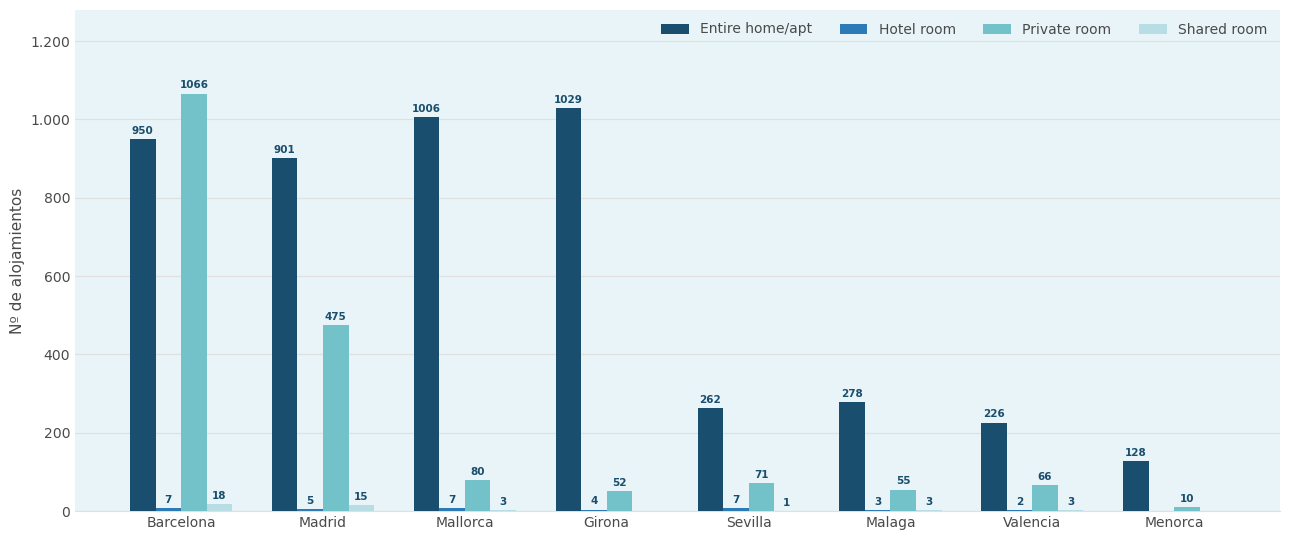

In [6]:
pivot_counts = (
    df.groupby(['city', 'room_type'])['apartment_id']
    .count()
    .unstack('room_type')
    .reindex(columns=TIPOS)
    .fillna(0)
)
pivot_counts = pivot_counts.loc[pivot_counts.sum(axis=1).sort_values(ascending=False).index]
city_labels  = [c.capitalize() for c in pivot_counts.index]

x       = np.arange(len(city_labels))
width   = 0.18
offsets = np.linspace(-(len(TIPOS) - 1) / 2, (len(TIPOS) - 1) / 2, len(TIPOS)) * width

fig, ax = plt.subplots(figsize=(13, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

for tipo, color, offset in zip(TIPOS, COLORES_TIPOS, offsets):
    vals = pivot_counts[tipo].values
    bars = ax.bar(x + offset, vals, width=width, color=color, label=tipo, zorder=3)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 8,
                    f'{int(val)}', ha='center', va='bottom',
                    fontsize=7.5, fontweight='bold', color=AZUL_OSCURO)

ax.set_xticks(x)
ax.set_xticklabels(city_labels, fontsize=11, color=GRIS_TEXTO)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'.replace(',', '.')))
ax.set_ylim(0, pivot_counts.values.max() * 1.2)
ax.set_ylabel('Nº de alojamientos', fontsize=11, color=GRIS_TEXTO)
ax.legend(frameon=False, fontsize=10, labelcolor=GRIS_TEXTO, loc='upper right', ncol=4)
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='both', length=0, labelsize=10, colors=GRIS_TEXTO)

plt.tight_layout()
# plt.savefig('fig5_ciudad_tipo_counts.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Este gráfico de barras agrupadas detalla la distribución del inventario de alojamientos por ciudad y tipo de habitación, permitiendo identificar la especialización de cada mercado. Barcelona destaca como el mercado más diverso y voluminoso, siendo la única ciudad donde las habitaciones privadas (1.066) superan en número a los apartamentos completos (950). En el resto de las ubicaciones, como Girona (1.029), Mallorca (1.006) y Madrid (901), el modelo de negocio predominante es claramente el de propiedades completas (Entire home/apt). Por último, el gráfico evidencia la escasez de habitaciones de hotel y compartidas en todas las ciudades, con cifras que raramente superan las 10 unidades por destino, lo que subraya un mercado orientado casi exclusivamente al alquiler vacacional residencial

## Fig 6 — Heatmap: precio medio por ciudad y tipo

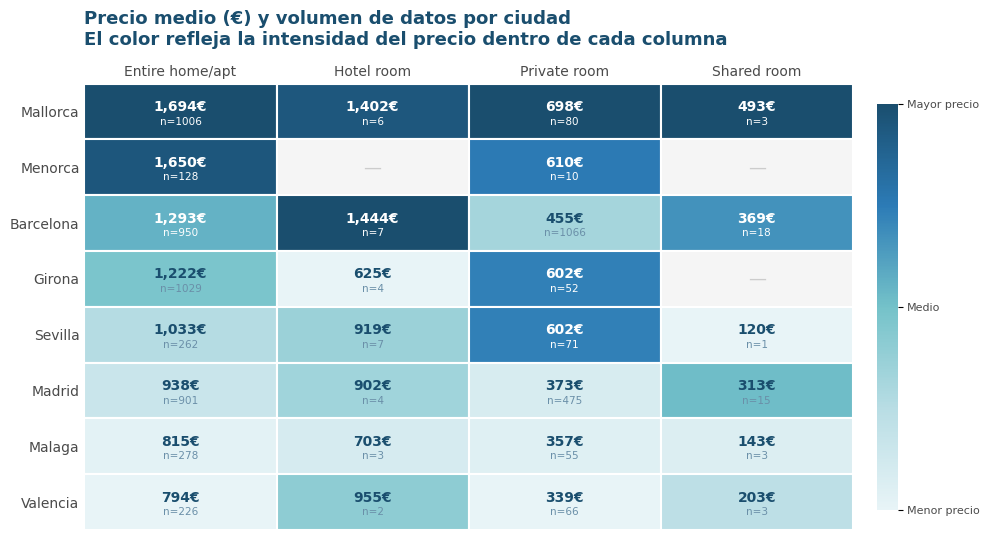

In [7]:

pivot_n = (
    df.groupby(['city', 'room_type'])['price_imputed']
    .count()
    .unstack('room_type')
    .reindex(columns=TIPOS)
    .loc[pivot_precio.index]
)

# 2. Configuración del mapa de colores
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_blue', [FONDO_SUAVE, AZUL_CLARO, TURQUESA, AZUL_PRINCIPAL, AZUL_OSCURO]
)

n_cities = len(pivot_precio)
n_tipos  = len(TIPOS)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# 3. Dibujo de las celdas
for j, tipo in enumerate(TIPOS):
    col_vals = pivot_precio[tipo].values.astype(float)
    col_ns   = pivot_n[tipo].values  # Extraemos los conteos para esta columna
    col_min, col_max = np.nanmin(col_vals), np.nanmax(col_vals)

    for i, (val, n, city) in enumerate(zip(col_vals, col_ns, CITY_LABELS)):
        x, y = j, n_cities - 1 - i
        
        if np.isnan(val):
            ax.add_patch(plt.Rectangle([x, y], 1, 1, facecolor='#F5F5F5', edgecolor='white', lw=1.5))
            ax.text(x + 0.5, y + 0.5, '—', ha='center', va='center', fontsize=13, color=GRIS_BORDE)
            continue
            
        # Normalización para el color
        norm_val = (val - col_min) / (col_max - col_min) if col_max > col_min else 0.5
        color_celda = cmap(norm_val)
        
        # Color del texto dinámico según el fondo
        text_color = 'white' if norm_val > 0.55 else AZUL_OSCURO
        sub_text_color = 'white' if norm_val > 0.55 else '#6A8FA8' # Un azul grisáceo para el 'n'

        # Dibujar rectángulo
        ax.add_patch(plt.Rectangle([x, y], 1, 1, facecolor=color_celda, edgecolor='white', lw=1.5))
        
        # Texto 1: Precio (arriba)
        ax.text(x + 0.5, y + 0.58, f'{val:,.0f}€',
                ha='center', va='center', fontsize=10, fontweight='bold', color=text_color)

        # Texto 2: Número de observaciones (abajo)
        ax.text(x + 0.5, y + 0.32, f'n={int(n)}',
                ha='center', va='center', fontsize=7.5, color=sub_text_color)

# 4. Estética de los ejes
ax.set_xlim(0, n_tipos)
ax.set_ylim(0, n_cities)
ax.set_xticks([j + 0.5 for j in range(n_tipos)])
ax.set_xticklabels(TIPOS, fontsize=10, color=GRIS_TEXTO)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')

ax.set_yticks([n_cities - 1 - i + 0.5 for i in range(n_cities)])
ax.set_yticklabels(CITY_LABELS, fontsize=10, color=GRIS_TEXTO)

ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

# Título y Barra de color
ax.set_title('Precio medio (€) y volumen de datos por ciudad\n'
             'El color refleja la intensidad del precio dentro de cada columna',
             fontsize=13, fontweight='bold', color=AZUL_OSCURO, pad=28, loc='left')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.03)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Menor precio', 'Medio', 'Mayor precio'], fontsize=8, color=GRIS_TEXTO)
cbar.outline.set_visible(False)

plt.tight_layout()
# plt.savefig('fig6_heatmap_media.png', dpi=150, bbox_inches='tight')
plt.show()

Este mapa de calor presenta una visión detallada del precio medio (€) y el volumen de observaciones ($n$) por ciudad y tipo de alojamiento. La visualización utiliza una escala de colores para representar la intensidad del precio dentro de cada categoría, permitiendo identificar rápidamente que Mallorca y Menorca poseen los precios medios más elevados para propiedades completas (1.694€ y 1.650€ respectivamente). Un aspecto fundamental de este gráfico es la inclusión del valor $n$, que otorga contexto sobre la fiabilidad estadística de cada dato; por ejemplo, el precio medio en Sevilla para habitaciones compartidas (120€) se basa en una sola observación ($n=1$), lo que sugiere cautela al generalizar dicho valor. En conjunto, el gráfico revela que, mientras ciudades como Barcelona mantienen precios altos con una base de datos muy amplia ($n=950$ para apartamentos), otros destinos muestran una oferta mucho más fragmentada o escasa en categorías específicas como las habitaciones de hotel.

## Fig 6.1 — Heatmap: mediana precio por ciudad y tipo

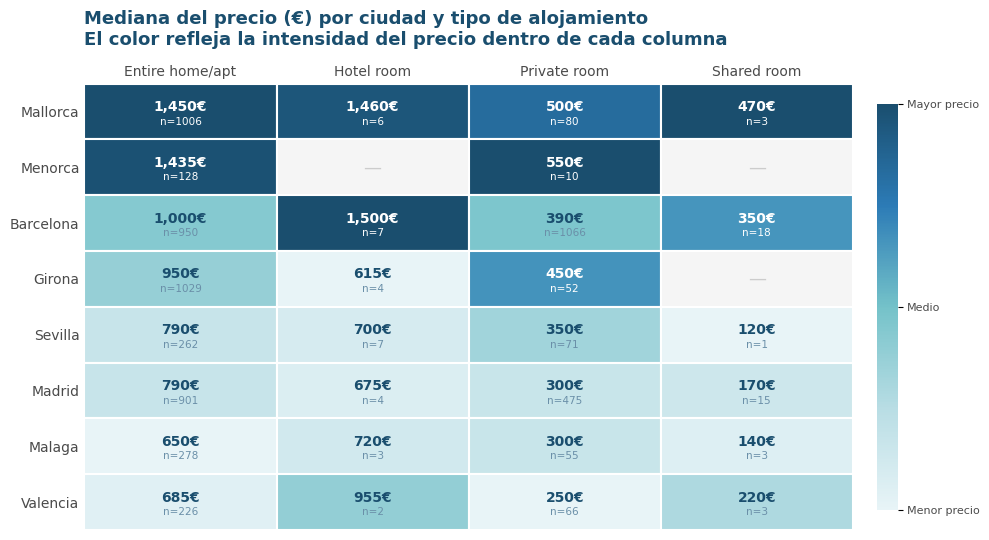

In [8]:
pivot_mediana = (
    df.groupby(['city', 'room_type'])['price_imputed']
    .median()
    .unstack('room_type')
    .reindex(columns=TIPOS)
    .loc[pivot_precio.index]
)
# ── Conteo de observaciones ───────────────────────────────────────────────────
pivot_n = (
    df.groupby(['city', 'room_type'])['price_imputed']
    .count()
    .unstack('room_type')
    .reindex(columns=TIPOS)
    .loc[pivot_precio.index]
)

cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_blue', [FONDO_SUAVE, AZUL_CLARO, TURQUESA, AZUL_PRINCIPAL, AZUL_OSCURO]
)

n_cities = len(pivot_mediana)
n_tipos  = len(TIPOS)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for j, tipo in enumerate(TIPOS):
    col_vals = pivot_mediana[tipo].values.astype(float)
    col_ns   = pivot_n[tipo].values                          # ← conteos
    col_min, col_max = np.nanmin(col_vals), np.nanmax(col_vals)

    for i, (val, n, city) in enumerate(zip(col_vals, col_ns, CITY_LABELS)):  # ← n en el zip
        x, y = j, n_cities - 1 - i
        if np.isnan(val):
            ax.add_patch(plt.Rectangle([x, y], 1, 1, facecolor='#F5F5F5', edgecolor='white', lw=1.5))
            ax.text(x + 0.5, y + 0.5, '—', ha='center', va='center', fontsize=13, color=GRIS_BORDE)
            continue
        norm_val   = (val - col_min) / (col_max - col_min) if col_max > col_min else 0.5
        text_color = 'white' if norm_val > 0.55 else AZUL_OSCURO

        ax.add_patch(plt.Rectangle([x, y], 1, 1, facecolor=cmap(norm_val), edgecolor='white', lw=1.5))

        # Precio — ligeramente por encima del centro
        ax.text(x + 0.5, y + 0.58, f'{val:,.0f}€',
                ha='center', va='center', fontsize=10, fontweight='bold', color=text_color)

        # N observaciones — debajo del precio
        ax.text(x + 0.5, y + 0.32, f'n={int(n)}',
                ha='center', va='center', fontsize=7.5,
                color='white' if norm_val > 0.55 else '#6A8FA8')

ax.set_xlim(0, n_tipos)
ax.set_ylim(0, n_cities)
ax.set_xticks([j + 0.5 for j in range(n_tipos)])
ax.set_xticklabels(TIPOS, fontsize=10, color=GRIS_TEXTO)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_yticks([n_cities - 1 - i + 0.5 for i in range(n_cities)])
ax.set_yticklabels(CITY_LABELS, fontsize=10, color=GRIS_TEXTO)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title('Mediana del precio (€) por ciudad y tipo de alojamiento\n'
             'El color refleja la intensidad del precio dentro de cada columna',
             fontsize=13, fontweight='bold', color=AZUL_OSCURO, pad=28, loc='left')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.03)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Menor precio', 'Medio', 'Mayor precio'], fontsize=8, color=GRIS_TEXTO)
cbar.outline.set_visible(False)

plt.tight_layout()
# plt.savefig('fig6b_heatmap_mediana.png', dpi=150, bbox_inches='tight')
plt.show()


Este mapa de calor visualiza la mediana del precio (€) por ciudad y tipo de alojamiento, ofreciendo una métrica más robusta frente a valores extremos que la media aritmética. Al igual que en el análisis anterior, el gráfico incluye el volumen de observaciones (n) para validar la representatividad de cada celda.

Los puntos clave que explica este gráfico son:

* Resiliencia de los Archipiélagos: Mallorca y Menorca mantienen las medianas más altas en apartamentos completos (1.450€ y 1.435€ respectivamente), lo que confirma un mercado de precios elevados de manera consistente.

* Barcelona y el sector Hotelero: En Barcelona, la mediana de las habitaciones de hotel (1.500€) es notablemente superior a la de los apartamentos (1.000€), sugiriendo una oferta hotelera enfocada al segmento de gama alta.

* Estabilidad en Grandes Ciudades: Madrid y Sevilla presentan una mediana idéntica de 790€ para apartamentos completos, mostrando una mayor homogeneidad en los precios del mercado urbano del interior y sur peninsular.

* Confiabilidad del Dato: La visualización permite distinguir rápidamente dónde los precios son estadísticamente sólidos, como en Girona con n=1029, frente a casos aislados como las habitaciones compartidas en Sevilla (n=1).

## Fig 7 — Entire home/apt vs Private room por ciudad

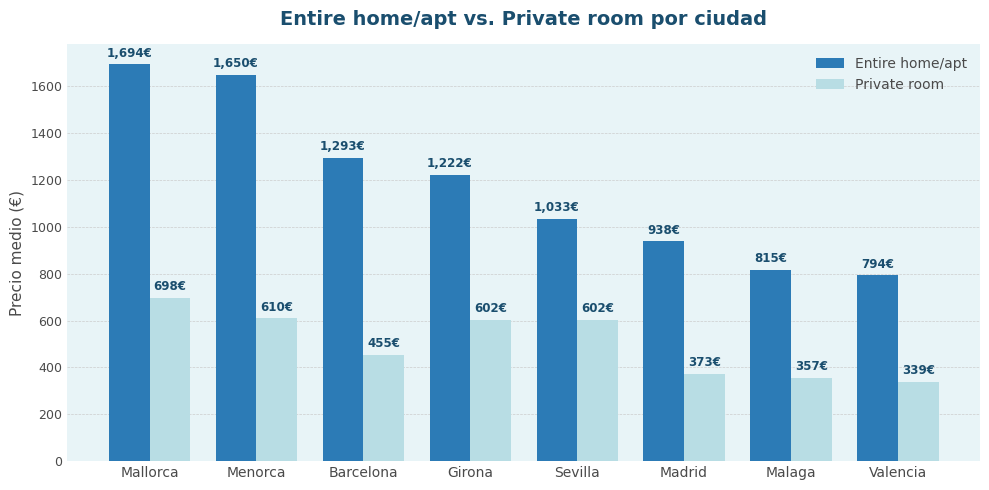

In [9]:
x       = np.arange(len(CITY_LABELS))
width   = 0.38
entire  = pivot_precio['Entire home/apt'].values
private = pivot_precio['Private room'].values

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

b1 = ax.bar(x - width/2, entire,  width, label='Entire home/apt', color=AZUL_PRINCIPAL, zorder=3)
b2 = ax.bar(x + width/2, private, width, label='Private room',    color=AZUL_CLARO,    zorder=3)

for bar, val in zip(b1, entire):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,.0f}€', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=AZUL_OSCURO)

for bar, val in zip(b2, private):
    if not np.isnan(val):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{val:,.0f}€', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=AZUL_OSCURO)

ax.set_xticks(x)
ax.set_xticklabels(CITY_LABELS, fontsize=10, color=GRIS_TEXTO)
ax.set_ylabel('Precio medio (€)', fontsize=11, color=GRIS_TEXTO)
ax.set_title('Entire home/apt vs. Private room por ciudad',
             fontsize=14, fontweight='bold', color=AZUL_OSCURO, pad=14)
ax.legend(frameon=False, fontsize=10, labelcolor=GRIS_TEXTO, loc='upper right')
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color=GRIS_BORDE, zorder=0)
ax.set_axisbelow(True)
ax.tick_params(axis='y', labelsize=9, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='x', length=0)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
# plt.savefig('fig7_barras_ciudad.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Este gráfico de barras comparativo muestra el precio medio por ciudad para los dos tipos de alojamiento más frecuentes: apartamentos completos (Entire home/apt) y habitaciones privadas (Private room). Permite visualizar de forma directa la brecha de precios entre ambas opciones en cada destino. Por ejemplo, en Mallorca, la diferencia es máxima, con apartamentos que cuestan de media 1.694€ frente a los 698€ de una habitación privada. En cambio, en ciudades como Madrid o Valencia, las barras son más bajas y la diferencia entre categorías es menor en términos absolutos, lo que indica mercados con precios más accesibles y equilibrados.

## Fig 8 — Dispersion precios entire home

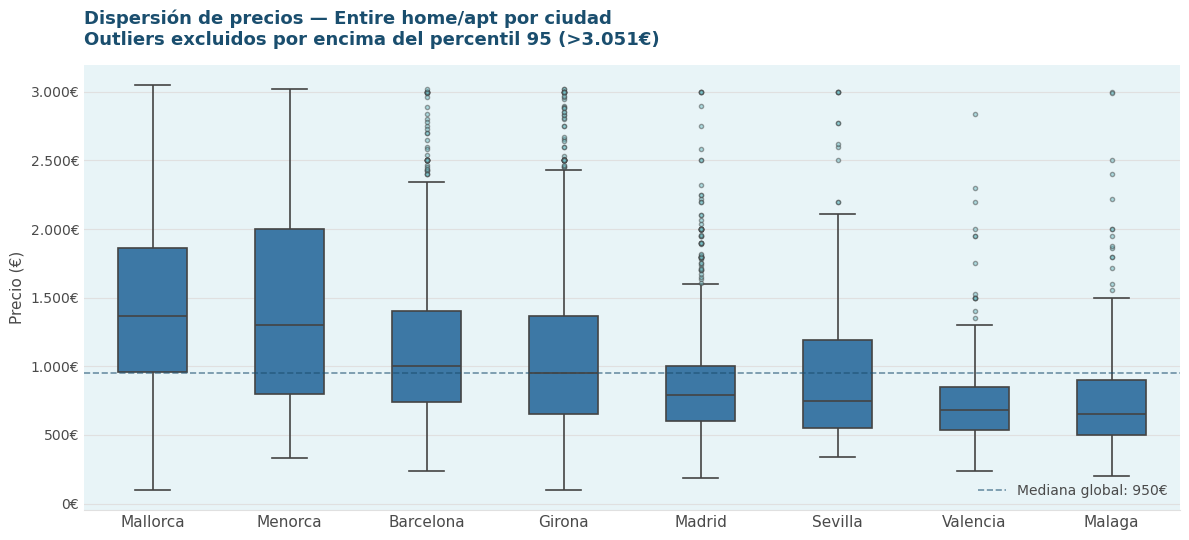

In [10]:
# Datos: solo Entire home/apt (segmento principal)
# Filtramos outliers extremos para que el gráfico sea legible
# (percentil 95 por ciudad para no distorsionar la escala)
p95 = df[df['room_type'] == 'Entire home/apt']['price_imputed'].quantile(0.95)
df_box = df[
    (df['room_type'] == 'Entire home/apt') &
    (df['price_imputed'] <= p95)
].copy()
df_box['city'] = df_box['city'].str.capitalize()

# Ordenar ciudades por mediana descendente
city_order = (
    df_box.groupby('city')['price_imputed']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor(FONDO_SUAVE)

sns.boxplot(
    data=df_box,
    x='city', y='price_imputed',
    order=city_order,
    color=AZUL_PRINCIPAL,
    width=0.5,
    linewidth=1.2,
    flierprops=dict(marker='o', markerfacecolor=TURQUESA,
                    markersize=3, linestyle='none', alpha=0.5),
    ax=ax
)

# Línea de mediana global como referencia
mediana_global = df_box['price_imputed'].median()
ax.axhline(mediana_global, linestyle='--', linewidth=1.2,
           color=AZUL_OSCURO, alpha=0.6,
           label=f'Mediana global: {mediana_global:,.0f}€'.replace(',', '.'))

ax.set_xlabel('', fontsize=11)
ax.set_ylabel('Precio (€)', fontsize=11, color=GRIS_TEXTO)
ax.set_title('Dispersión de precios — Entire home/apt por ciudad\n'
             f'Outliers excluidos por encima del percentil 95 (>{p95:,.0f}€)'.replace(',', '.'),
             fontsize=13, fontweight='bold', color=AZUL_OSCURO, pad=14, loc='left')
ax.legend(frameon=False, fontsize=10, labelcolor=GRIS_TEXTO)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}€'.replace(',', '.')))
ax.yaxis.grid(True, linestyle='-', linewidth=0.8, color=GRIS_GRID, zorder=0)
ax.set_axisbelow(True)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(GRIS_GRID)
ax.tick_params(axis='x', labelsize=11, colors=GRIS_TEXTO, length=0)
ax.tick_params(axis='y', labelsize=10, colors=GRIS_TEXTO, length=0)

plt.tight_layout()
# plt.savefig('fig8_boxplot_dispersion.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Este gráfico analiza la dispersión y variabilidad de precios para la categoría de apartamentos completos en cada ciudad, estableciendo una mediana global de 950€ como punto de referencia. Las cajas representan el rango donde se concentra el 50% central de la oferta; se observa que Mallorca y Menorca presentan las cajas más amplias y altas, lo que indica un mercado muy heterogéneo con una gran diferencia entre los alojamientos estándar y los de lujo. Por el contrario, ciudades como Málaga y Valencia muestran cajas mucho más compactas y situadas por debajo de la mediana global, reflejando mercados con precios más predecibles y accesibles. Los puntos individuales por encima de los bigotes representan valores atípicos (outliers) que, aun habiendo excluido el 5% más extremo (por encima de 3.051€), demuestran que todavía existe un segmento de oferta con precios significativamente superiores al comportamiento habitual de cada ciudad.

## Fig 9 - Precio por persona

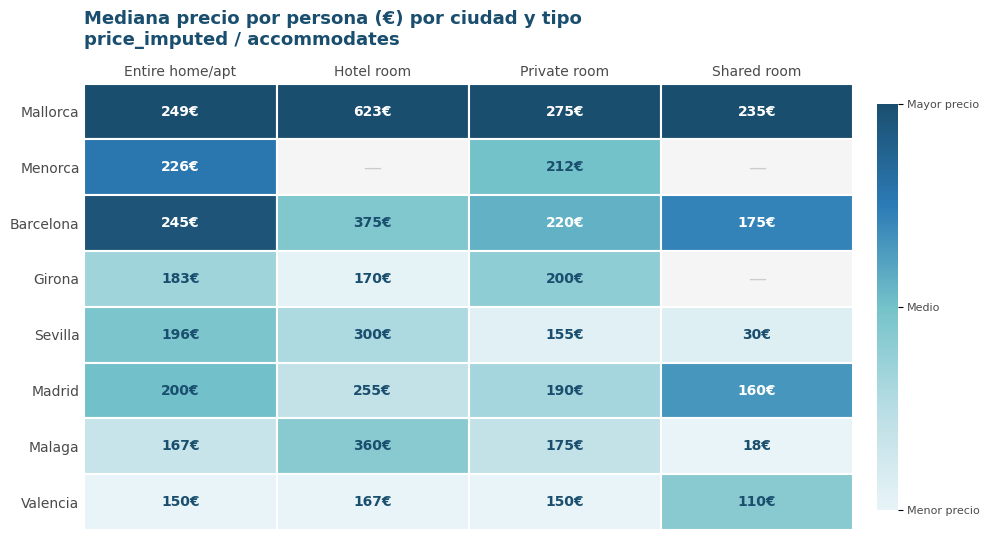

In [11]:
# ── Cálculo ───────────────────────────────────────────────────────────────────
df['price_per_person'] = df['price_imputed'] / df['accommodates']

pivot_ppp = (
    df.groupby(['city', 'room_type'])['price_per_person']
    .median()
    .unstack('room_type')
    .reindex(columns=TIPOS)
    .loc[pivot_precio.index]
)

# ── Heatmap (mismo estilo que los anteriores) ─────────────────────────────────
cmap = mcolors.LinearSegmentedColormap.from_list(
    'custom_blue', [FONDO_SUAVE, AZUL_CLARO, TURQUESA, AZUL_PRINCIPAL, AZUL_OSCURO]
)

n_cities = len(pivot_ppp)
n_tipos  = len(TIPOS)

fig, ax = plt.subplots(figsize=(10, 5.5))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

for j, tipo in enumerate(TIPOS):
    col_vals = pivot_ppp[tipo].values.astype(float)
    col_min, col_max = np.nanmin(col_vals), np.nanmax(col_vals)

    for i, (val, city) in enumerate(zip(col_vals, CITY_LABELS)):
        x, y = j, n_cities - 1 - i
        if np.isnan(val):
            ax.add_patch(plt.Rectangle([x, y], 1, 1, facecolor='#F5F5F5', edgecolor='white', lw=1.5))
            ax.text(x + 0.5, y + 0.5, '—', ha='center', va='center', fontsize=13, color=GRIS_BORDE)
            continue
        norm_val   = (val - col_min) / (col_max - col_min) if col_max > col_min else 0.5
        text_color = 'white' if norm_val > 0.55 else AZUL_OSCURO
        ax.add_patch(plt.Rectangle([x, y], 1, 1, facecolor=cmap(norm_val), edgecolor='white', lw=1.5))
        ax.text(x + 0.5, y + 0.5, f'{val:,.0f}€'.replace(',', '.'),
                ha='center', va='center', fontsize=10, fontweight='bold', color=text_color)

ax.set_xlim(0, n_tipos)
ax.set_ylim(0, n_cities)
ax.set_xticks([j + 0.5 for j in range(n_tipos)])
ax.set_xticklabels(TIPOS, fontsize=10, color=GRIS_TEXTO)
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
ax.set_yticks([n_cities - 1 - i + 0.5 for i in range(n_cities)])
ax.set_yticklabels(CITY_LABELS, fontsize=10, color=GRIS_TEXTO)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_title('Mediana precio por persona (€) por ciudad y tipo\n'
             'price_imputed / accommodates',
             fontsize=13, fontweight='bold', color=AZUL_OSCURO, pad=28, loc='left')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=mcolors.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', fraction=0.025, pad=0.03)
cbar.set_ticks([0, 0.5, 1])
cbar.set_ticklabels(['Menor precio', 'Medio', 'Mayor precio'], fontsize=8, color=GRIS_TEXTO)
cbar.outline.set_visible(False)

plt.tight_layout()
# plt.savefig('fig9_precio_persona.png', dpi=150, bbox_inches='tight')
plt.show()

Este mapa de calor presenta la mediana del precio por persona (calculada como el precio total dividido entre la capacidad de alojamiento), lo que permite normalizar el coste y comparar la eficiencia económica de cada opción. A diferencia de los gráficos de precio total, aquí se observa que las habitaciones de hotel son, en términos relativos, la opción más costosa por individuo, alcanzando un máximo de 623€ por persona en Mallorca y 375€ en Barcelona. En contraste, aunque los apartamentos completos tienen precios totales elevados, su coste por persona se mantiene más competitivo (entre 150€ y 249€), debido a su mayor capacidad de huéspedes. Este enfoque revela oportunidades estratégicas para el marketing, identificando a Valencia y Málaga como los destinos más eficientes para el viajero individual o en grupos pequeños, con precios por debajo de los 170€ en casi todas las categorías.

## FIg 10 - Relacion precio-pontuacion

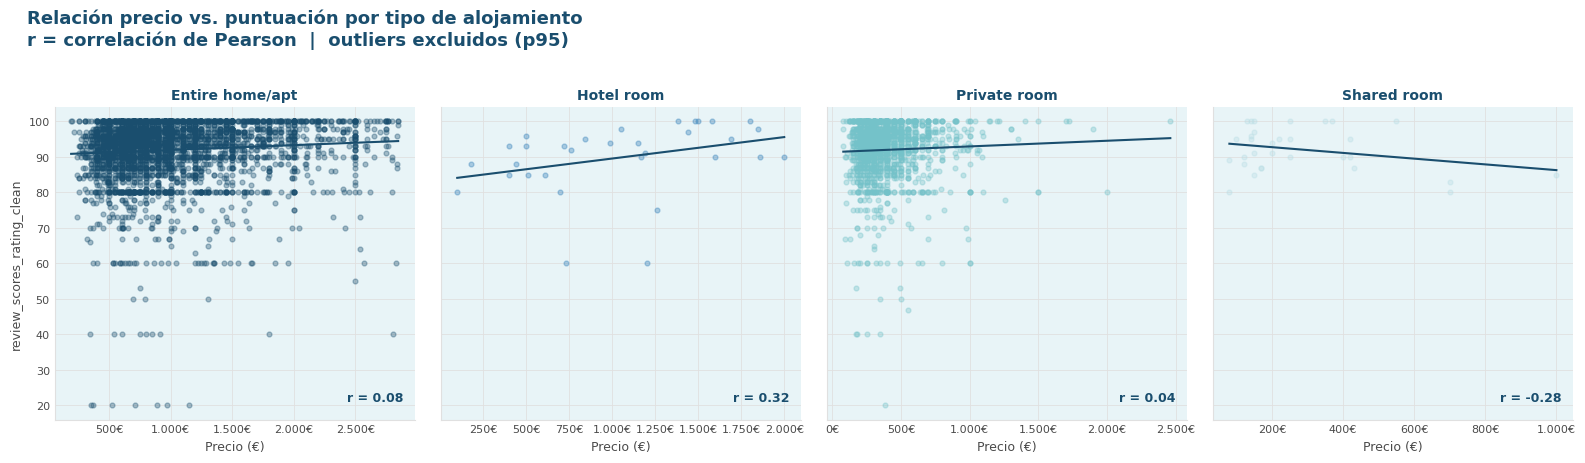

In [12]:
# ── Datos: excluir NaN en rating y outliers de precio ────────────────────────
p95 = df['price_imputed'].quantile(0.95)
df_scatter = df[
    df['review_scores_rating_clean'].notna() &
    (df['price_imputed'] <= p95)
].copy()
df_scatter['city'] = df_scatter['city'].str.capitalize()

# ── Figura: un scatter por tipo de alojamiento ────────────────────────────────
fig, axes = plt.subplots(1, len(TIPOS), figsize=(16, 4.5), sharey=True)
fig.patch.set_facecolor('white')

for ax, tipo, color in zip(axes, TIPOS, COLORES_TIPOS):
    subset = df_scatter[df_scatter['room_type'] == tipo]
    ax.set_facecolor(FONDO_SUAVE)

    ax.scatter(
        subset['price_imputed'],
        subset['review_scores_rating_clean'],
        color=color, alpha=0.35, s=12, zorder=3
    )

    # Línea de tendencia
    if len(subset) > 10:
        z   = np.polyfit(subset['price_imputed'], subset['review_scores_rating_clean'], 1)
        p   = np.poly1d(z)
        xs  = np.linspace(subset['price_imputed'].min(), subset['price_imputed'].max(), 100)
        ax.plot(xs, p(xs), color=AZUL_OSCURO, linewidth=1.5, zorder=4)

        # Correlación
        corr = subset['price_imputed'].corr(subset['review_scores_rating_clean'])
        ax.text(0.97, 0.05, f'r = {corr:.2f}',
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=9, color=AZUL_OSCURO, fontweight='bold')

    ax.set_title(tipo, fontsize=10, fontweight='bold', color=AZUL_OSCURO)
    ax.set_xlabel('Precio (€)', fontsize=9, color=GRIS_TEXTO)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}€'.replace(',', '.')))
    ax.yaxis.grid(True, linestyle='-', linewidth=0.6, color=GRIS_GRID, zorder=0)
    ax.xaxis.grid(True, linestyle='-', linewidth=0.6, color=GRIS_GRID, zorder=0)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_color(GRIS_GRID)
    ax.tick_params(axis='both', labelsize=8, colors=GRIS_TEXTO, length=0)

axes[0].set_ylabel('review_scores_rating_clean', fontsize=9, color=GRIS_TEXTO)

fig.suptitle('Relación precio vs. puntuación por tipo de alojamiento\n'
             'r = correlación de Pearson  |  outliers excluidos (p95)',
             fontsize=13, fontweight='bold', color=AZUL_OSCURO, x=0.02, ha='left', y=1.02)

plt.tight_layout()
# plt.savefig('fig10_review_scores_rating_clean.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

Este último análisis utiliza diagramas de dispersión para evaluar la relación entre el precio y la puntuación de los usuarios, utilizando el coeficiente de correlación de Pearson ($r$) como indicador de predicción de calidad. En la categoría predominante de Entire home/apt, se observa un valor de $r = 0.08$, lo que se sitúa en el rango de $r \approx 0$; esto indica que no existe una relación lineal y que, por lo tanto, el precio no predice la calidad percibida por el cliente. Un hallazgo particularmente llamativo aparece en las Shared rooms, donde el coeficiente es de $r = -0.28$; al ser un valor $r < 0$, sugiere una tendencia donde los alojamientos más caros tienen peor puntuación en este segmento. En definitiva, estos datos rompen el mito de que un mayor desembolso garantiza una mejor experiencia, subrayando que la satisfacción del cliente depende de factores ajenos al coste de la reserva.